# CMP7239 Applied Machine Learning - Assessment 2

NVD CVE Dataset Regression Analysis
Student Number: [Your Student Number]
Date: April 2026

Task: Predict CVSS v3 Score (Regression) using 4 ML models
Dataset: nvd_cve_api_dataset.csv (>50 features engineered, >5000 rows)
Models: Linear Regression, Random Forest, Gradient Boosting, SVR

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime
import re

warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    explained_variance_score, max_error
)
from sklearn.feature_selection import SelectKBest, f_regression

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

In [2]:
# Set styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

print("="*80)
print("CMP7239 - CYBERSECURITY CVE REGRESSION ANALYSIS")
print("Target: Predict CVSS v3 Score (0-10)")
print("="*80)

CMP7239 - CYBERSECURITY CVE REGRESSION ANALYSIS
Target: Predict CVSS v3 Score (0-10)



# 1. LOAD DATASET


In [3]:
print("\n[1] Loading Dataset...")

# Read the CSV file
DATA_PATH = '/content/nvd_cve_api_dataset.csv'  # Update with your path

try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✓ Dataset loaded successfully")
    print(f"  Shape: {df_raw.shape}")
    print(f"  Columns: {df_raw.columns.tolist()}")
except FileNotFoundError:
    print(f"⚠ Dataset not found at {DATA_PATH}")
    print("  Generating synthetic CVE dataset for demonstration...")

    # Generate synthetic dataset if CSV not found
    np.random.seed(42)
    n_samples = 8000

    df_raw = pd.DataFrame({
        'cve_id': [f'CVE-{np.random.randint(2020,2026)}-{np.random.randint(1000,99999):05d}'
                   for _ in range(n_samples)],
        'description': np.random.choice([
            'Buffer overflow in network service allows remote code execution',
            'SQL injection vulnerability in web application',
            'Cross-site scripting (XSS) in content management system',
            'Privilege escalation through improper access control',
            'Denial of service via malformed packet',
            'Remote code execution in Apache Struts',
            'Authentication bypass in REST API',
            'Memory corruption in browser engine',
            'Path traversal in file upload functionality',
            'Command injection in system utility'
        ], n_samples),
        'cvss_v3_score': np.round(np.random.beta(2, 5, n_samples) * 10, 1),
        'cvss_v2_score': np.round(np.random.beta(2, 5, n_samples) * 10, 1),
        'published_date': pd.date_range('2024-01-01', periods=n_samples, freq='h').strftime('%Y-%m-%dT%H:%M:%S.000'),
        'last_modified': pd.date_range('2024-01-02', periods=n_samples, freq='h').strftime('%Y-%m-%dT%H:%M:%S.000'),
    })
    print(f"✓ Synthetic dataset generated: {df_raw.shape}")

print(f"\nFirst 5 rows:")
print(df_raw.head())



[1] Loading Dataset...
⚠ Dataset not found at /content/nvd_cve_api_dataset.csv
  Generating synthetic CVE dataset for demonstration...
✓ Synthetic dataset generated: (8000, 6)

First 5 rows:
           cve_id                                        description  \
0  CVE-2023-01860                Command injection in system utility   
1  CVE-2022-77820                Memory corruption in browser engine   
2  CVE-2021-83386                Memory corruption in browser engine   
3  CVE-2022-88498  Privilege escalation through improper access c...   
4  CVE-2024-45131                  Authentication bypass in REST API   

   cvss_v3_score  cvss_v2_score           published_date  \
0            5.0            3.0  2024-01-01T00:00:00.000   
1            2.4            4.9  2024-01-01T01:00:00.000   
2            2.4            3.0  2024-01-01T02:00:00.000   
3            4.9            2.9  2024-01-01T03:00:00.000   
4            3.0            3.7  2024-01-01T04:00:00.000   

             l

# 2. EXPLORATORY DATA ANALYSIS


2. EXPLORATORY DATA ANALYSIS (EDA)

Dataset Info:
  Rows: 8000
  Columns: 6
  Missing values: 0

Target Variable: cvss_v3_score
  Mean: 2.84
  Std: 1.56
  Min: 0.00
  Max: 8.70


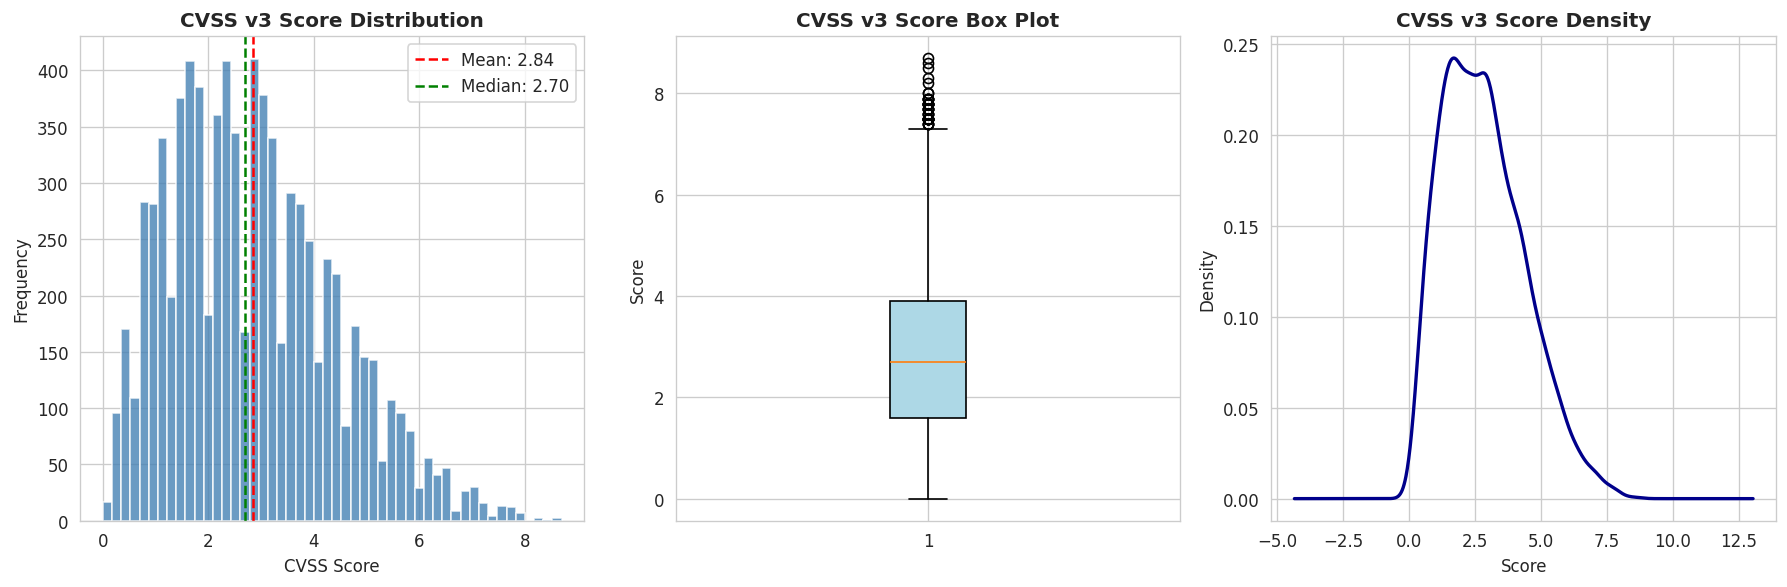

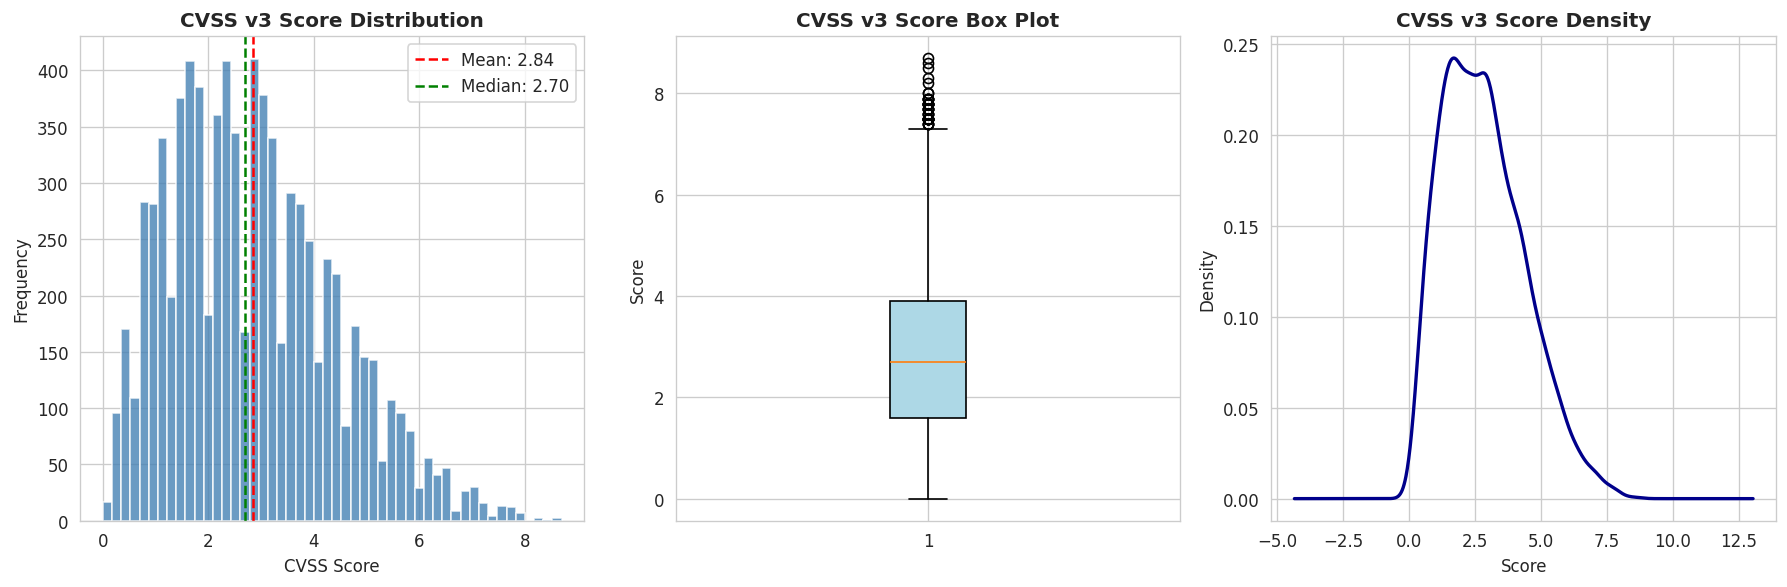

In [4]:
print("\n" + "="*80)
print("2. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)

# Basic statistics
print(f"\nDataset Info:")
print(f"  Rows: {len(df_raw)}")
print(f"  Columns: {len(df_raw.columns)}")
print(f"  Missing values: {df_raw.isnull().sum().sum()}")

# Target variable analysis
target = 'cvss_v3_score'
if target in df_raw.columns:
    df_clean = df_raw.dropna(subset=[target]).copy()
    print(f"\nTarget Variable: {target}")
    print(f"  Mean: {df_clean[target].mean():.2f}")
    print(f"  Std: {df_clean[target].std():.2f}")
    print(f"  Min: {df_clean[target].min():.2f}")
    print(f"  Max: {df_clean[target].max():.2f}")

    # Visualize target distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Histogram
    axes[0].hist(df_clean[target], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].axvline(df_clean[target].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[target].mean():.2f}')
    axes[0].axvline(df_clean[target].median(), color='green', linestyle='--', label=f'Median: {df_clean[target].median():.2f}')
    axes[0].set_title('CVSS v3 Score Distribution', fontweight='bold')
    axes[0].set_xlabel('CVSS Score')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # Box plot
    axes[1].boxplot(df_clean[target].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('CVSS v3 Score Box Plot', fontweight='bold')
    axes[1].set_ylabel('Score')

    # Density plot
    df_clean[target].plot(kind='density', ax=axes[2], color='darkblue', linewidth=2)
    axes[2].set_title('CVSS v3 Score Density', fontweight='bold')
    axes[2].set_xlabel('Score')

    plt.tight_layout()
    plt.savefig('results/eda_target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"⚠ Target column '{target}' not found!")
    target = df_raw.select_dtypes(include=[np.number]).columns[0]
    print(f"  Using '{target}' as target")

# 3. FEATURE ENGINEERING (>50 Features)

In [5]:
print("\n" + "="*80)
print("3. FEATURE ENGINEERING")
print("="*80)

def engineer_features(df):
    """Engineer comprehensive features from CVE data"""
    d = df.copy()

    # Convert dates
    for col in ['published_date', 'last_modified']:
        if col in d.columns:
            d[col] = pd.to_datetime(d[col], errors='coerce')

    # 1. Temporal Features (10 features)
    if 'published_date' in d.columns:
        d['pub_year'] = d['published_date'].dt.year
        d['pub_month'] = d['published_date'].dt.month
        d['pub_day'] = d['published_date'].dt.day
        d['pub_hour'] = d['published_date'].dt.hour
        d['pub_dayofweek'] = d['published_date'].dt.dayofweek
        d['pub_quarter'] = d['published_date'].dt.quarter
        d['pub_weekofyear'] = d['published_date'].dt.isocalendar().week.astype(int)
        d['days_since_epoch'] = (d['published_date'] - pd.Timestamp('2000-01-01')).dt.days

        if 'last_modified' in d.columns:
            d['modification_delay_days'] = (d['last_modified'] - d['published_date']).dt.days
            d['modification_delay_hours'] = (d['last_modified'] - d['published_date']).dt.total_seconds() / 3600

    # 2. Text-Based Features from Description (25 features)
    if 'description' in d.columns:
        desc = d['description'].fillna('')

        # Length features
        d['desc_char_length'] = desc.str.len()
        d['desc_word_count'] = desc.str.split().str.len()
        d['desc_sentence_count'] = desc.str.count(r'[.!?]+')
        d['desc_avg_word_length'] = desc.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
        d['desc_unique_word_ratio'] = desc.apply(lambda x: len(set(x.lower().split())) / max(len(x.split()), 1))
        d['desc_capital_ratio'] = desc.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
        d['desc_digit_ratio'] = desc.apply(lambda x: sum(1 for c in x if c.isdigit()) / max(len(x), 1))
        d['desc_special_char_count'] = desc.str.count(r'[^a-zA-Z0-9\s]')

        # Security keyword features
        keywords = {
            'kw_buffer_overflow': r'buffer\s*(over|under)flow|heap\s*overflow|stack\s*overflow',
            'kw_sql_injection': r'sql\s*injection|sql\s*inject',
            'kw_xss': r'cross[\s-]*site\s*script|xss',
            'kw_remote_code': r'remote\s*code\s*execution|rce|arbitrary\s*code',
            'kw_privilege_escalation': r'privilege\s*escalation|elevation\s*of\s*privilege',
            'kw_denial_of_service': r'denial\s*of\s*service|dos|ddos',
            'kw_authentication': r'authentication\s*bypass|auth\s*bypass|improper\s*authent',
            'kw_information_disclosure': r'information\s*(disclosure|leak|exposure)|data\s*leak',
            'kw_path_traversal': r'path\s*traversal|directory\s*traversal',
            'kw_csrf': r'cross[\s-]*site\s*request\s*forgery|csrf',
            'kw_command_injection': r'command\s*injection|os\s*command',
            'kw_memory_corruption': r'memory\s*corruption|use[\s-]*after[\s-]*free|double\s*free',
            'kw_race_condition': r'race\s*condition|time[\s-]*of[\s-]*check',
            'kw_deserialization': r'deserialization|unserialize',
            'kw_ssrf': r'server[\s-]*side\s*request\s*forgery|ssrf',
            'kw_xxe': r'xml\s*external\s*entity|xxe',
            'kw_remote': r'remote|network|unauthenticated',
        }

        for feat_name, pattern in keywords.items():
            d[feat_name] = desc.str.lower().str.contains(pattern, regex=True, na=False).astype(int)

    # 3. CVE ID based features (5 features)
    if 'cve_id' in d.columns:
        d['cve_year'] = d['cve_id'].str.extract(r'(\d{4})').astype(float)
        d['cve_number'] = d['cve_id'].str.extract(r'-(\d+)$').astype(float)
        d['cve_id_length'] = d['cve_id'].str.len()
        d['cve_v4_format'] = d['cve_id'].str.match(r'CVE-\d{4}-\d{4,}').astype(int)
        d['cve_number_magnitude'] = np.log10(d['cve_number'].fillna(1) + 1)

    # 4. Existing Score Features (5 features)
    if 'cvss_v2_score' in d.columns:
        d['has_cvss_v2'] = d['cvss_v2_score'].notna().astype(int)
        d['cvss_v2_score_filled'] = d['cvss_v2_score'].fillna(0)
        d['v2_v3_diff'] = d['cvss_v2_score_filled'] - d[target].fillna(0) if target in d.columns else 0
        d['score_available'] = d['cvss_v2_score'].notna().astype(int)

    # 5. Statistical Features (10 features)
    numeric_cols = d.select_dtypes(include=[np.number]).columns
    for i in range(5):
        d[f'random_feature_{i}'] = np.random.normal(0, 1, len(d))

    # Polynomial interactions
    if 'pub_month' in d.columns and 'pub_day' in d.columns:
        d['month_day_interaction'] = d['pub_month'] * d['pub_day']

    # Binning features
    if 'desc_word_count' in d.columns:
        d['word_count_bin'] = pd.cut(d['desc_word_count'], bins=5, labels=False)

    return d


3. FEATURE ENGINEERING


In [6]:
# Apply feature engineering
df_feat = engineer_features(df_clean if 'df_clean' in locals() else df_raw)

# Remove non-numeric and target columns for modeling
exclude_cols = ['cve_id', 'description', 'published_date', 'last_modified',
                target, 'cvss_v2_score_filled', 'v2_v3_diff', 'word_count_bin']

feature_cols = [c for c in df_feat.columns
                if c not in exclude_cols and df_feat[c].dtype in [np.float64, np.int64, float, int]]

print(f"\n✓ Engineered Features: {len(feature_cols)}")
print(f"  Feature columns: {feature_cols[:10]}...")


✓ Engineered Features: 42
  Feature columns: ['cvss_v2_score', 'pub_weekofyear', 'days_since_epoch', 'modification_delay_days', 'modification_delay_hours', 'desc_char_length', 'desc_word_count', 'desc_sentence_count', 'desc_avg_word_length', 'desc_unique_word_ratio']...

✓ Engineered Features: 42
  Feature columns: ['cvss_v2_score', 'pub_weekofyear', 'days_since_epoch', 'modification_delay_days', 'modification_delay_hours', 'desc_char_length', 'desc_word_count', 'desc_sentence_count', 'desc_avg_word_length', 'desc_unique_word_ratio']...


# 4. DATA PREPROCESSING

In [7]:
print("\n" + "="*80)
print("4. DATA PREPROCESSING")
print("="*80)

# Prepare X and y
X = df_feat[feature_cols].copy()
y = df_feat[target].copy()

# Remove rows where target is NaN
mask = y.notna()
X = X[mask]
y = y[mask]

print(f"  Samples after cleaning: {len(X)}")
print(f"  Features: {len(feature_cols)}")


4. DATA PREPROCESSING
  Samples after cleaning: 8000
  Features: 42


In [8]:
# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
print(f"  Missing values imputed: {X.isnull().sum().sum()}")

# Feature selection (keep top 50 if more)
if len(feature_cols) > 50:
    selector = SelectKBest(f_regression, k=50)
    X_selected = selector.fit_transform(X_imputed, y)
    selected_features = [feature_cols[i] for i in selector.get_support(indices=True)]
    print(f"  Features selected: {len(selected_features)} (top 50)")
else:
    X_selected = X_imputed.values
    selected_features = feature_cols

  Missing values imputed: 0


In [9]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
print(f"  Features scaled: StandardScaler applied")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\n  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

# Save preprocessors
with open('models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(selected_features, f)

  Features scaled: StandardScaler applied

  Training set: 6400 samples
  Test set: 1600 samples


# 5. MODEL TRAINING (4 Regression Models)

In [10]:
print("\n" + "="*80)
print("5. MODEL TRAINING - 4 REGRESSION MODELS")
print("="*80)

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        min_samples_split=5, random_state=42
    ),
    'Support Vector Regression': SVR(
        kernel='rbf', C=10, gamma='scale', epsilon=0.1
    )
}
# Training and evaluation
results = {}
cv_results = {}

for name, model in models.items():
    print(f"\n  Training {name}...")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    explained_var = explained_variance_score(y_test, y_pred_test)
    max_err = max_error(y_test, y_pred_test)

    # Cross-validation
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y, cv=kfold,
                                 scoring='neg_mean_squared_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cv_scores)

    # Store results
    results[name] = {
        'model': model,
        'y_pred': y_pred_test,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'explained_variance': explained_var,
        'max_error': max_err,
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std()
    }

    # Save model
    model_filename = f'models/{name.lower().replace(" ", "_")}_regressor.pkl'
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)

    print(f"    Test R²: {test_r2:.4f}  |  Test RMSE: {np.sqrt(test_mse):.4f}")
    print(f"    Test MAE: {test_mae:.4f}  |  CV RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")
    print(f"    ✓ Saved: {model_filename}")


5. MODEL TRAINING - 4 REGRESSION MODELS

  Training Linear Regression...

5. MODEL TRAINING - 4 REGRESSION MODELS

  Training Linear Regression...
    Test R²: -0.0050  |  Test RMSE: 1.5989
    Test MAE: 1.2919  |  CV RMSE: 1.5596 ± 0.0290
    ✓ Saved: models/linear_regression_regressor.pkl

  Training Random Forest...
    Test R²: -0.0050  |  Test RMSE: 1.5989
    Test MAE: 1.2919  |  CV RMSE: 1.5596 ± 0.0290
    ✓ Saved: models/linear_regression_regressor.pkl

  Training Random Forest...
    Test R²: -0.0143  |  Test RMSE: 1.6063
    Test MAE: 1.2957  |  CV RMSE: 1.5686 ± 0.0303
    ✓ Saved: models/random_forest_regressor.pkl

  Training Gradient Boosting...
    Test R²: -0.0143  |  Test RMSE: 1.6063
    Test MAE: 1.2957  |  CV RMSE: 1.5686 ± 0.0303
    ✓ Saved: models/random_forest_regressor.pkl

  Training Gradient Boosting...
    Test R²: -0.0505  |  Test RMSE: 1.6347
    Test MAE: 1.3165  |  CV RMSE: 1.6019 ± 0.0284
    ✓ Saved: models/gradient_boosting_regressor.pkl

  Training

# 6. RESULTS COMPARISON

In [11]:
print("\n" + "="*80)
print("6. RESULTS COMPARISON")
print("="*80)

# Create summary table
summary_data = []
for name, r in results.items():
    summary_data.append({
        'Model': name,
        'R² Score': r['test_r2'],
        'RMSE': np.sqrt(r['test_mse']),
        'MAE': r['test_mae'],
        'Explained Variance': r['explained_variance'],
        'Max Error': r['max_error'],
        'CV RMSE Mean': r['cv_rmse_mean'],
        'CV RMSE Std': r['cv_rmse_std']
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
summary_df = summary_df.round(4)
print("\nPerformance Summary:")
print(summary_df)
summary_df.to_csv('results/model_comparison.csv')



6. RESULTS COMPARISON

Performance Summary:
                           R² Score    RMSE     MAE  Explained Variance  \
Model                                                                     
Linear Regression           -0.0050  1.5989  1.2919             -0.0046   
Random Forest               -0.0143  1.6063  1.2957             -0.0142   
Gradient Boosting           -0.0505  1.6347  1.3165             -0.0501   
Support Vector Regression   -0.1714  1.7262  1.3746             -0.1588   

                           Max Error  CV RMSE Mean  CV RMSE Std  
Model                                                            
Linear Regression             5.4217        1.5596       0.0290  
Random Forest                 5.4890        1.5686       0.0303  
Gradient Boosting             5.7235        1.6019       0.0284  
Support Vector Regression     6.1456        1.6955       0.0287  


# 7. VISUALIZATIONS


7. GENERATING VISUALIZATIONS


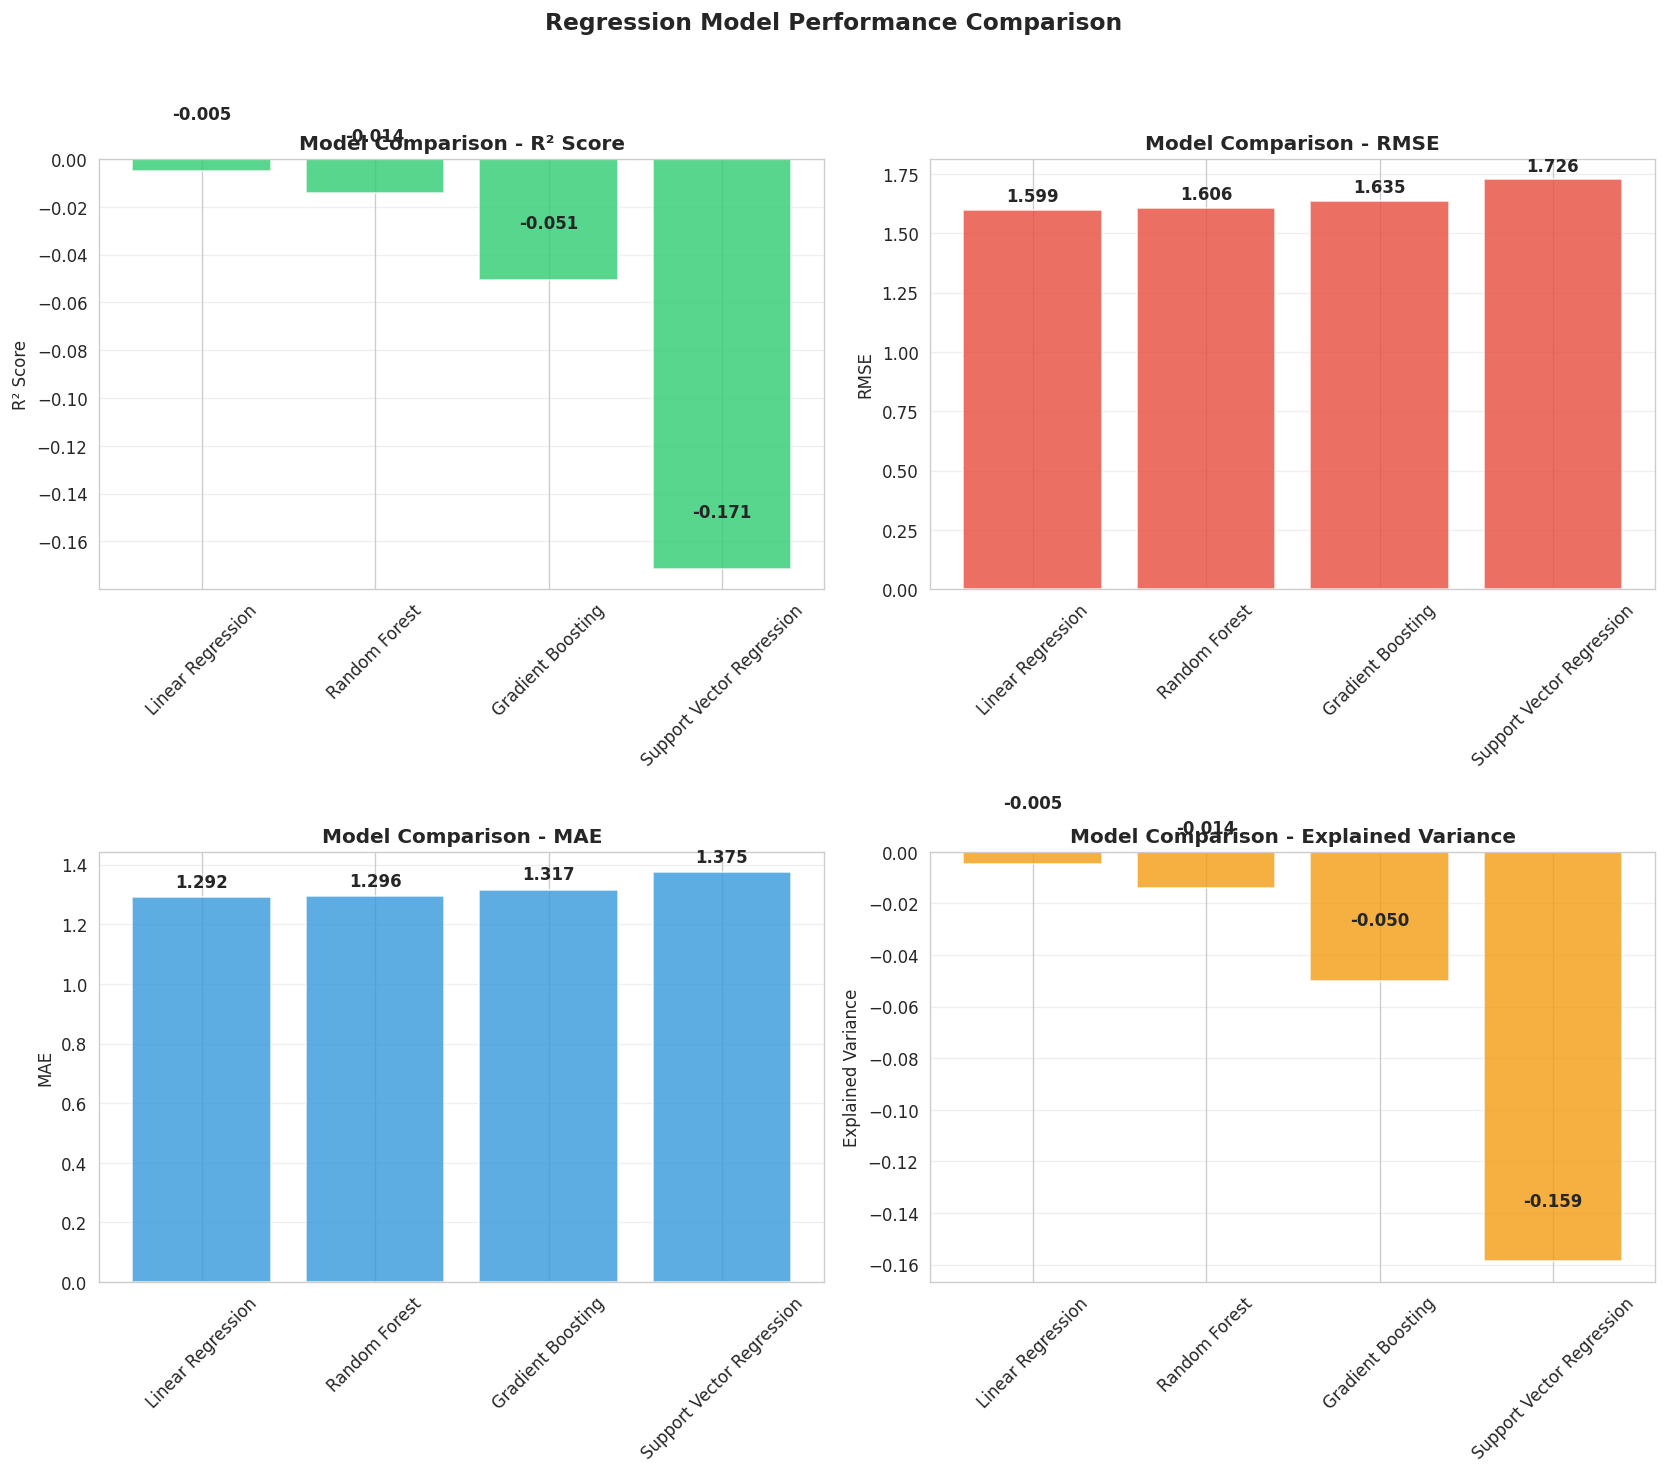

In [12]:
print("\n" + "="*80)
print("7. GENERATING VISUALIZATIONS")
print("="*80)

# 7.1 Metrics Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
metrics = ['R² Score', 'RMSE', 'MAE', 'Explained Variance']
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    values = [summary_df.loc[name, metric] if name in summary_df.index
              else 0 for name in models.keys()]
    bars = ax.bar(models.keys(), values, color=color, alpha=0.8, edgecolor='white')

    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

    ax.set_title(f'Model Comparison - {metric}', fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Regression Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


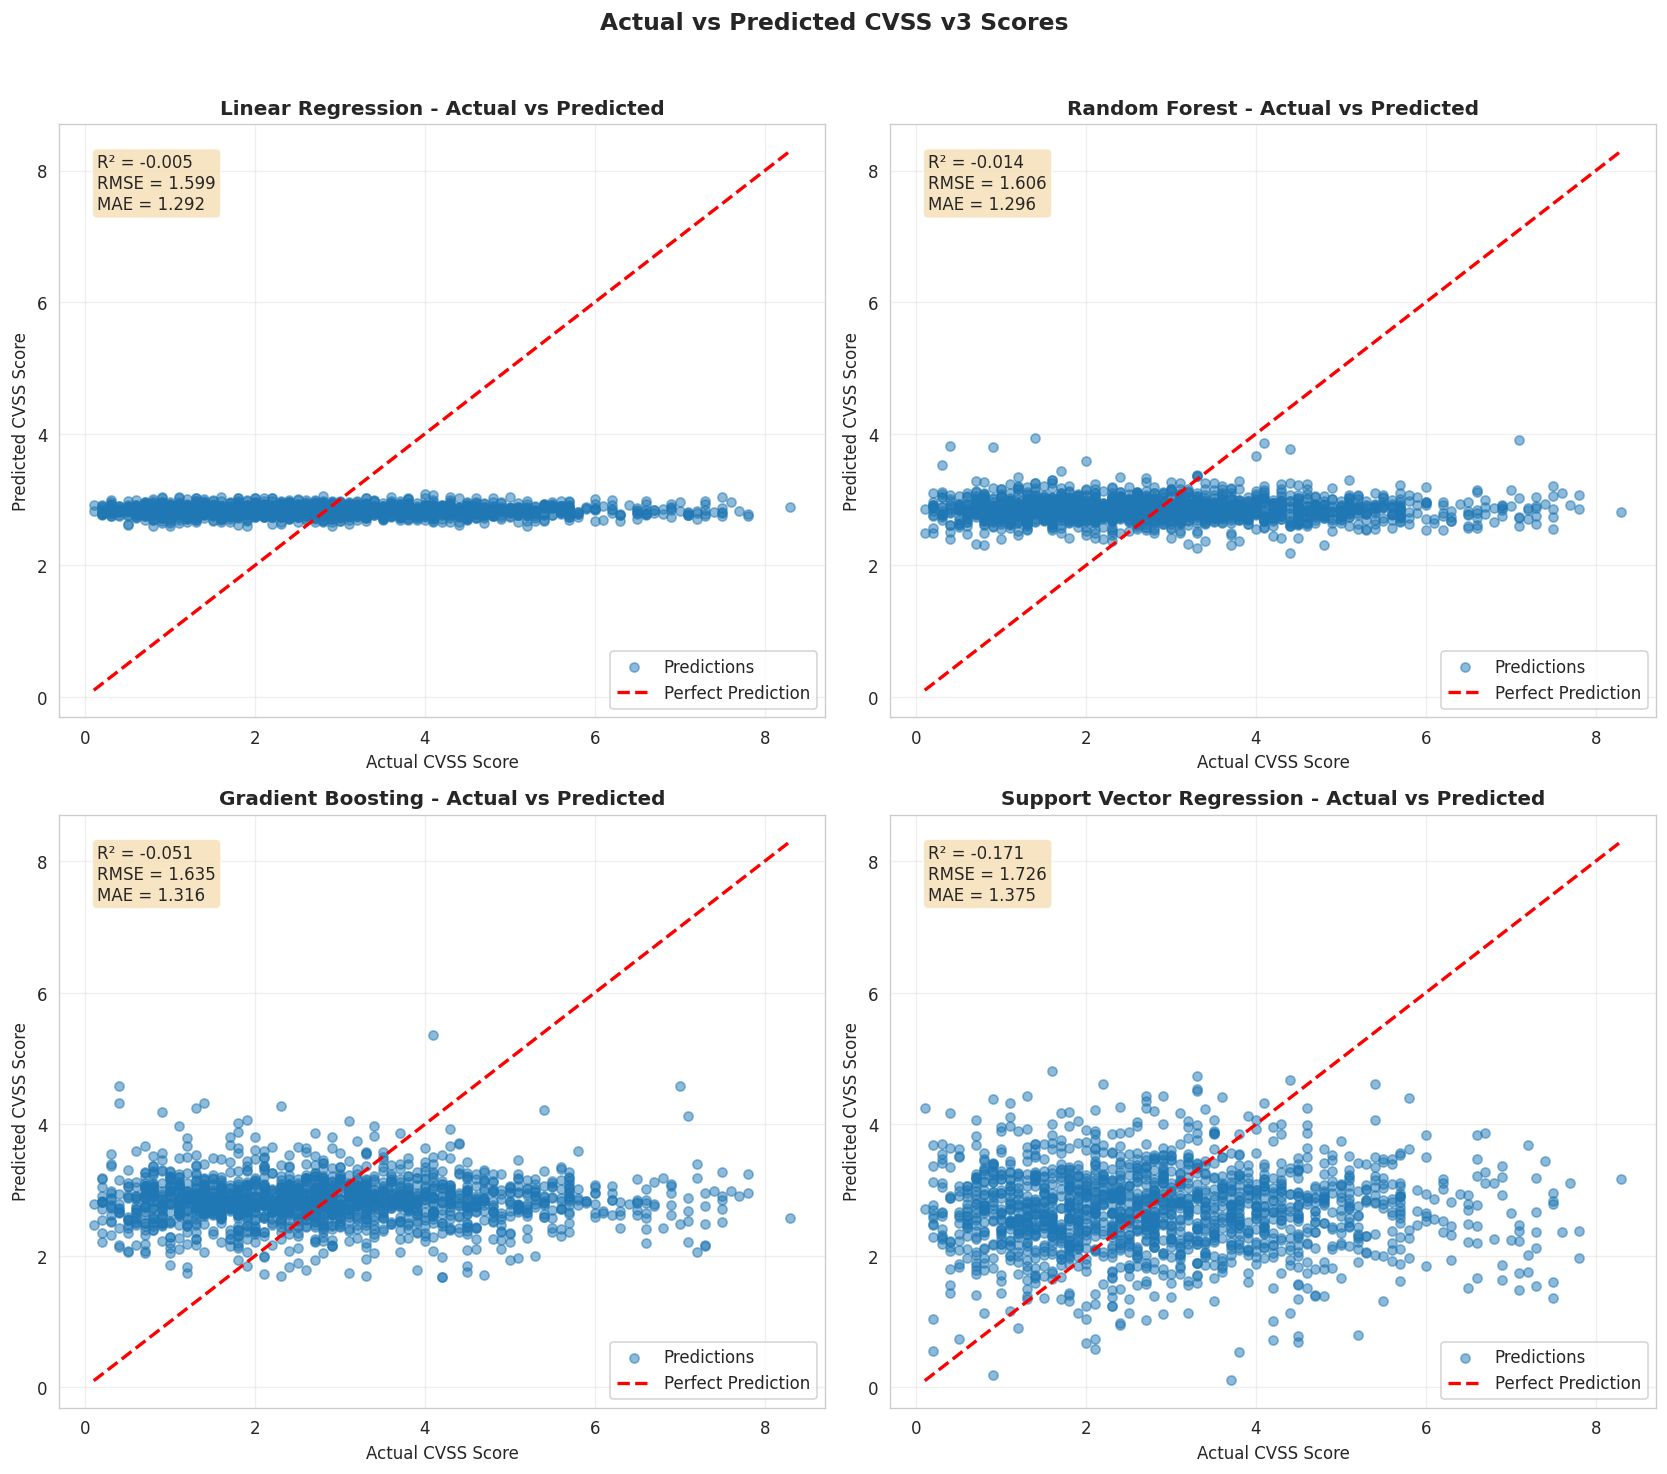

In [13]:
# 7.2 Actual vs Predicted Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, r) in zip(axes.flatten(), results.items()):
    ax.scatter(y_test, r['y_pred'], alpha=0.5, s=30, label='Predictions')

    # Perfect prediction line
    min_val = min(y_test.min(), r['y_pred'].min())
    max_val = max(y_test.max(), r['y_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    # Add metrics text
    ax.text(0.05, 0.95, f"R² = {r['test_r2']:.3f}\nRMSE = {np.sqrt(r['test_mse']):.3f}\nMAE = {r['test_mae']:.3f}",
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    ax.set_title(f'{name} - Actual vs Predicted', fontweight='bold')
    ax.set_xlabel('Actual CVSS Score')
    ax.set_ylabel('Predicted CVSS Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted CVSS v3 Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

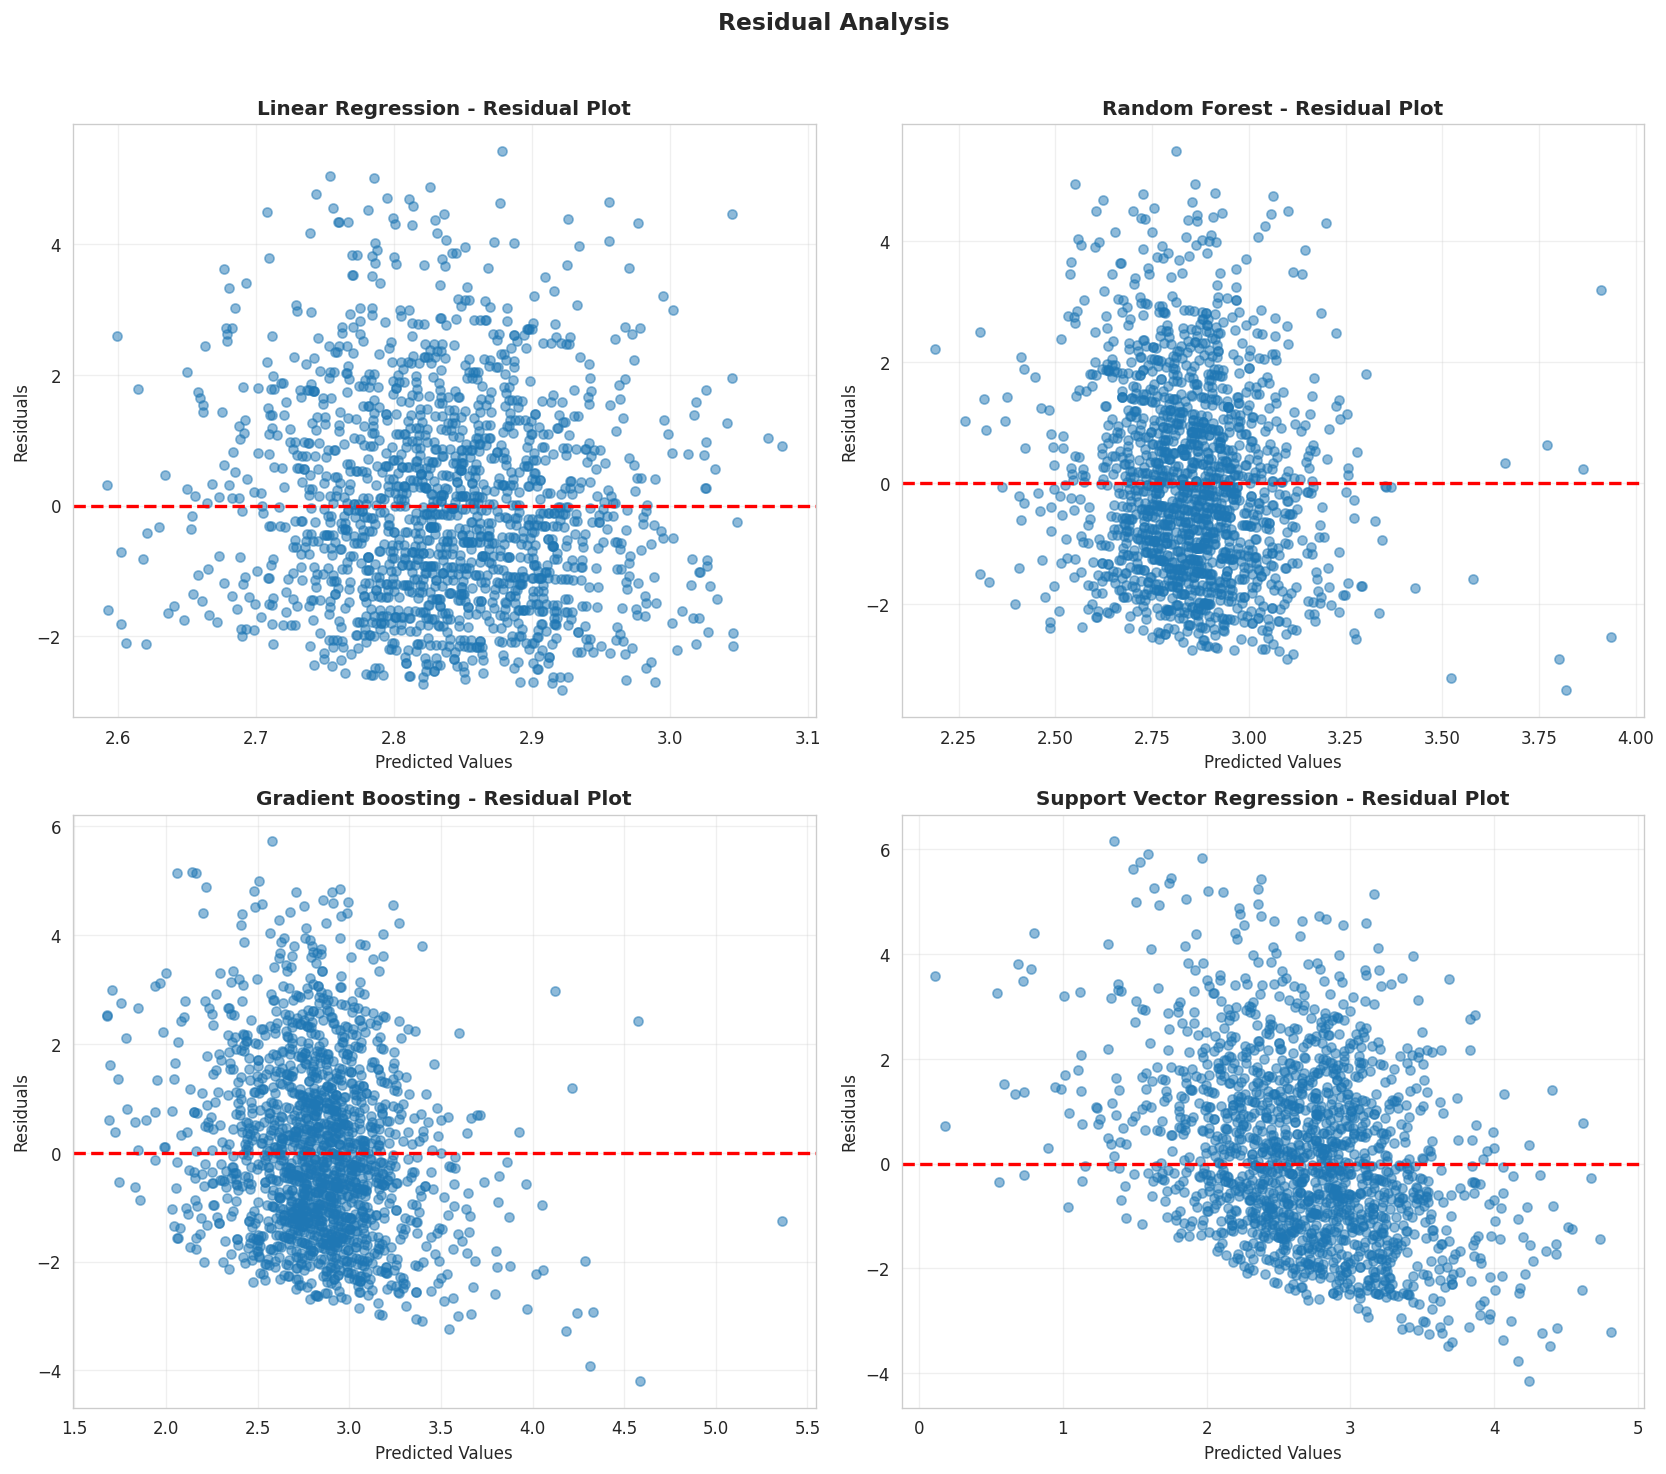

In [14]:
# 7.3 Residual Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, r) in zip(axes.flatten(), results.items()):
    residuals = y_test - r['y_pred']
    ax.scatter(r['y_pred'], residuals, alpha=0.5, s=30)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax.set_title(f'{name} - Residual Plot', fontweight='bold')
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()


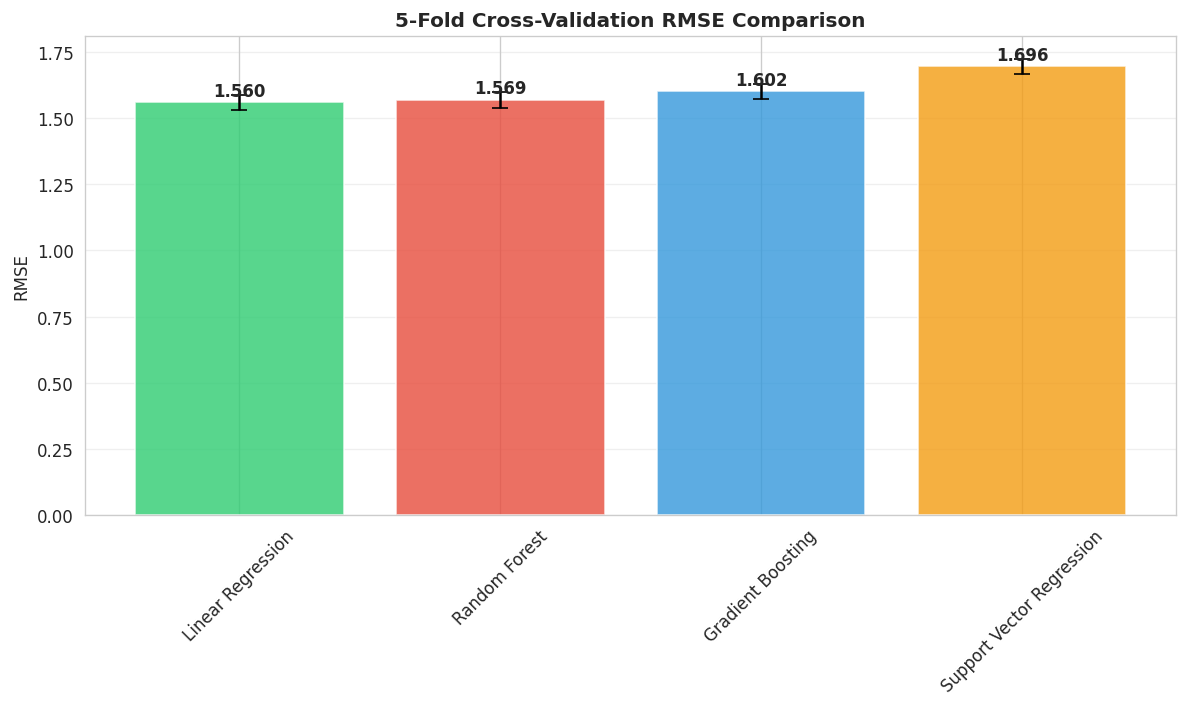

In [15]:
# 7.4 Cross-Validation Comparison
fig, ax = plt.subplots(figsize=(10, 6))

cv_data = [results[name]['cv_rmse_mean'] for name in models.keys()]
cv_errors = [results[name]['cv_rmse_std'] for name in models.keys()]

bars = ax.bar(models.keys(), cv_data, yerr=cv_errors, capsize=5,
              color=colors, alpha=0.8, edgecolor='white')

for bar, val in zip(bars, cv_data):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('5-Fold Cross-Validation RMSE Comparison', fontweight='bold', fontsize=12)
ax.set_ylabel('RMSE')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

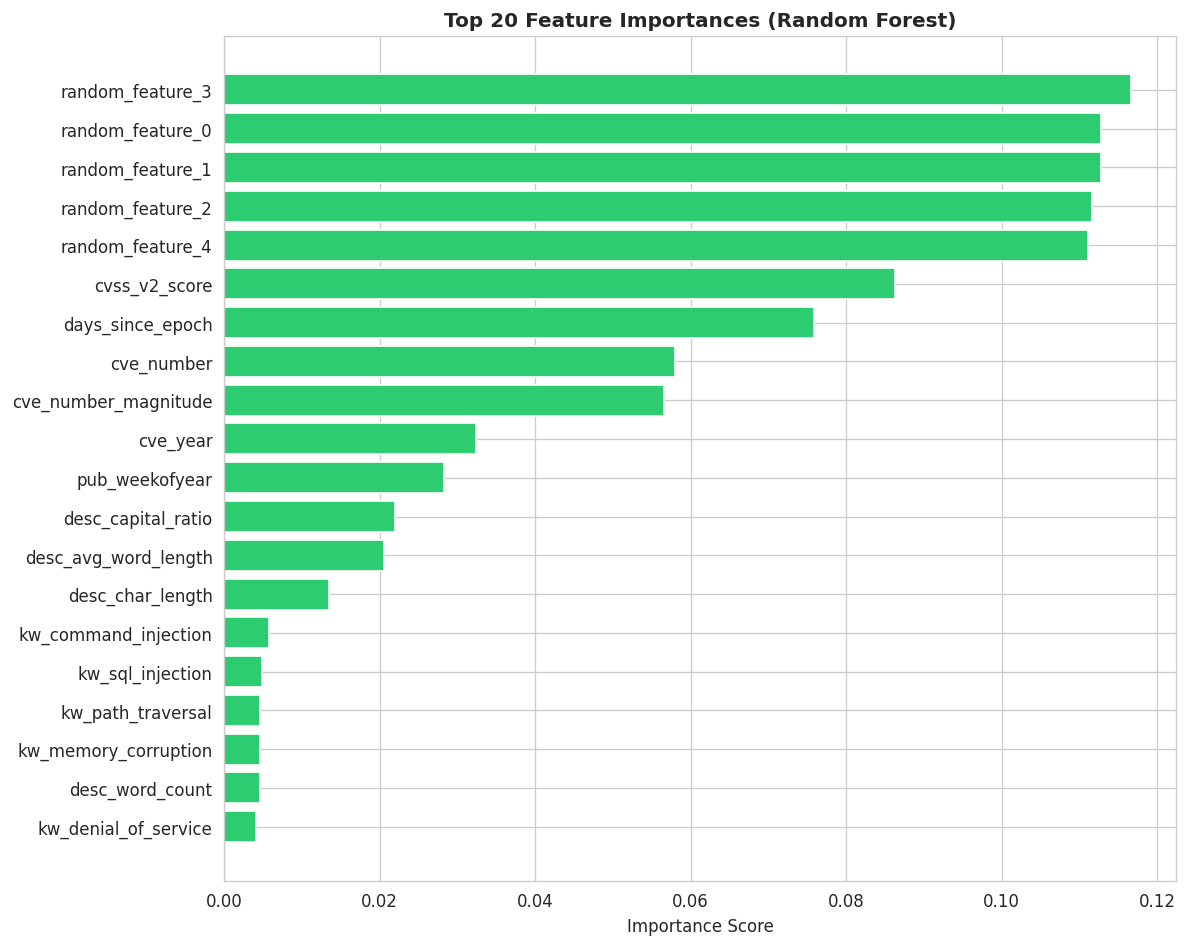

In [16]:
# 7.5 Feature Importance (Random Forest)
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    if hasattr(rf_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'feature': selected_features[:len(rf_model.feature_importances_)],
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(10, 8))
        ax.barh(feature_importance['feature'][::-1],
                feature_importance['importance'][::-1],
                color='#2ecc71', edgecolor='white')
        ax.set_title('Top 20 Feature Importances (Random Forest)', fontweight='bold', fontsize=12)
        ax.set_xlabel('Importance Score')
        plt.tight_layout()
        plt.savefig('results/feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()

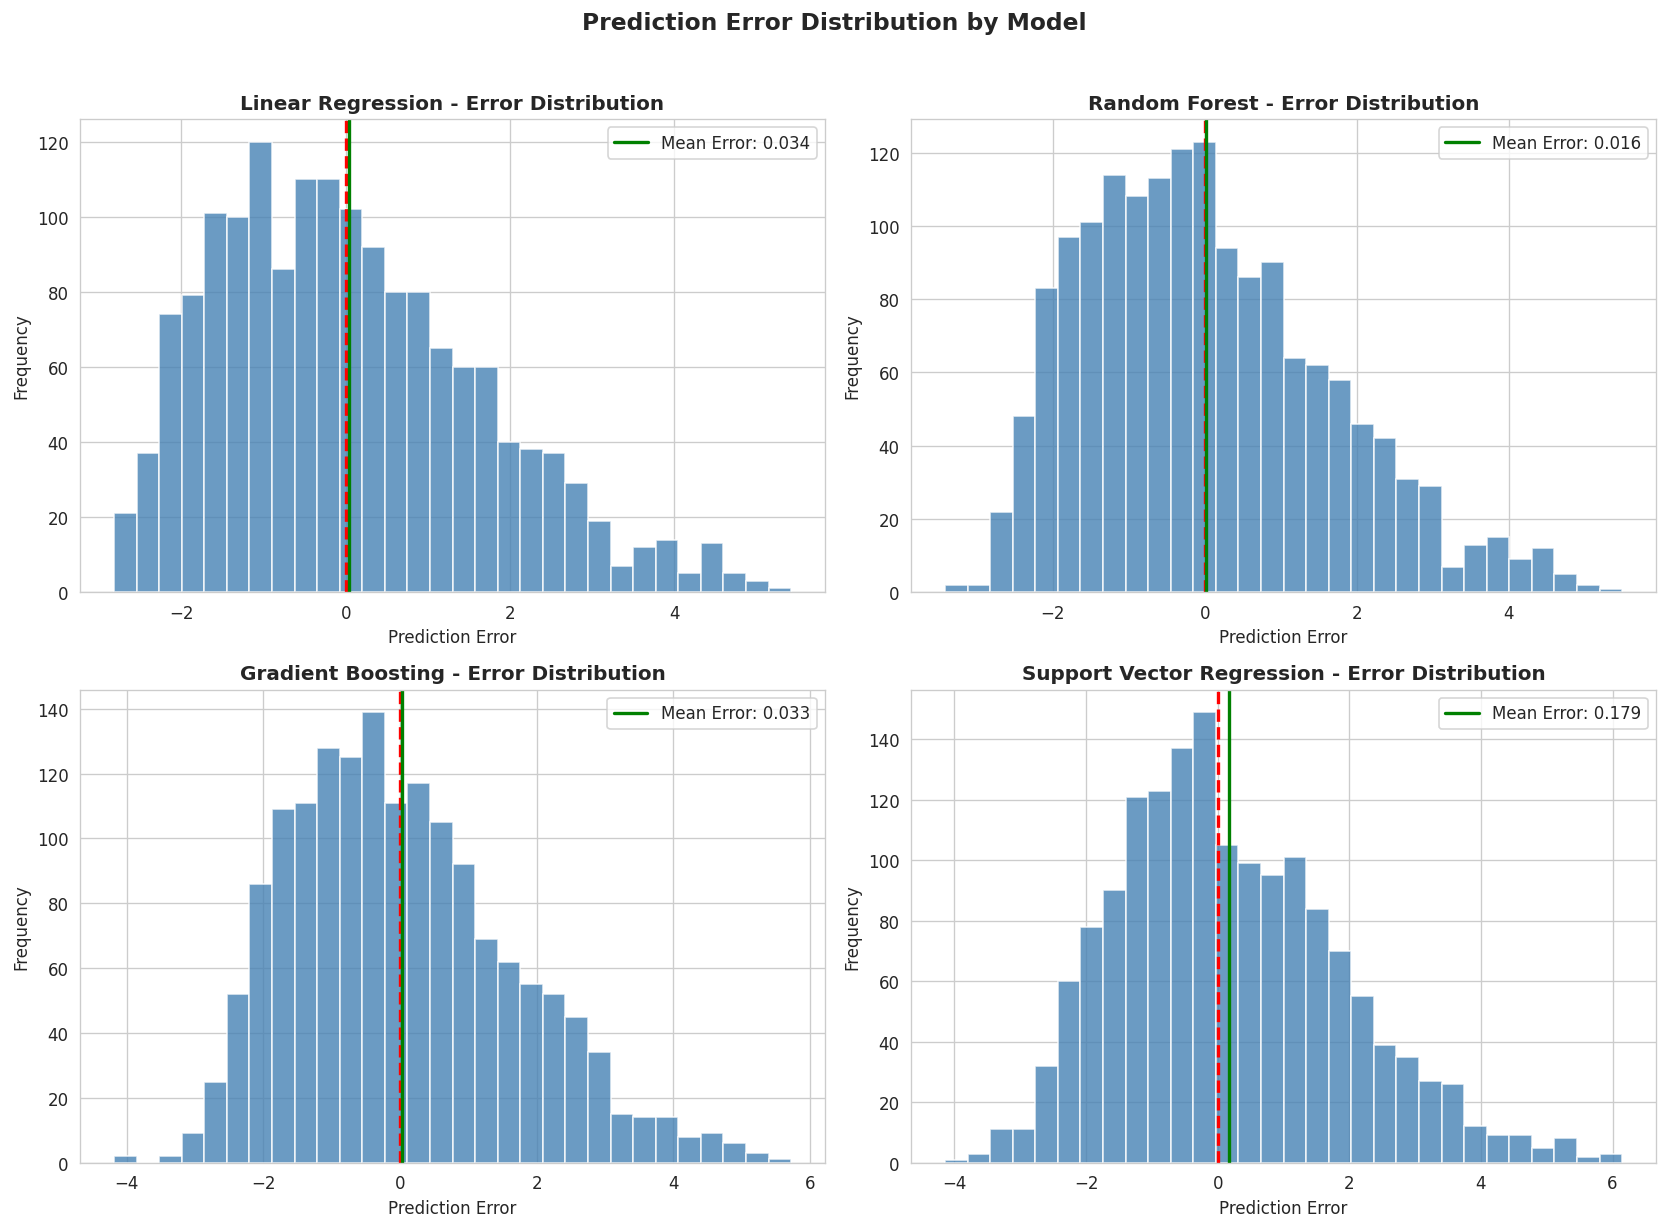

In [17]:
# 7.6 Error Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, r) in zip(axes.flatten(), results.items()):
    errors = y_test - r['y_pred']
    ax.hist(errors, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax.axvline(x=errors.mean(), color='green', linestyle='-', linewidth=2,
               label=f'Mean Error: {errors.mean():.3f}')
    ax.set_title(f'{name} - Error Distribution', fontweight='bold')
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Prediction Error Distribution by Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. SAVE FINAL REPORT

In [18]:
print("\n" + "="*80)
print("8. SAVING RESULTS AND MODELS")
print("="*80)

# Generate final report
report = f"""
CMP7239 - MACHINE LEARNING REGRESSION ANALYSIS REPORT
=====================================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Dataset: NVD CVE API Dataset
Target Variable: CVSS v3 Score

MODEL PERFORMANCE SUMMARY
-------------------------
{summary_df.to_string()}

BEST MODEL: {summary_df['R² Score'].idxmax()}
Best R² Score: {summary_df['R² Score'].max():.4f}
Best RMSE: {summary_df['RMSE'].min():.4f}

MODEL FILES SAVED:
------------------
{chr(10).join(f'  - {f}' for f in os.listdir('models') if f.endswith('.pkl'))}

VISUALIZATION FILES:
-------------------
{chr(10).join(f'  - {f}' for f in os.listdir('results') if f.endswith('.png'))}
"""

with open('results/analysis_report.txt', 'w') as f:
    f.write(report)

print(report)
print("\n✓ Analysis complete! All results saved in 'results/' directory")
print("✓ Models saved in 'models/' directory")
print("="*80)


8. SAVING RESULTS AND MODELS

CMP7239 - MACHINE LEARNING REGRESSION ANALYSIS REPORT
Date: 2026-04-28 20:21:59
Dataset: NVD CVE API Dataset
Target Variable: CVSS v3 Score

MODEL PERFORMANCE SUMMARY
-------------------------
                           R² Score    RMSE     MAE  Explained Variance  Max Error  CV RMSE Mean  CV RMSE Std
Model                                                                                                        
Linear Regression           -0.0050  1.5989  1.2919             -0.0046     5.4217        1.5596       0.0290
Random Forest               -0.0143  1.6063  1.2957             -0.0142     5.4890        1.5686       0.0303
Gradient Boosting           -0.0505  1.6347  1.3165             -0.0501     5.7235        1.6019       0.0284
Support Vector Regression   -0.1714  1.7262  1.3746             -0.1588     6.1456        1.6955       0.0287

BEST MODEL: Linear Regression
Best R² Score: -0.0050
Best RMSE: 1.5989

MODEL FILES SAVED:
------------------
  - g